<a href="https://colab.research.google.com/github/Frankieche24/AVCAD-Assignment/blob/main/Avcad_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports and data loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data
df = pd.read_csv('EFIplus_medit.zip', compression='zip', sep=';')
df.drop(df.iloc[:, 5:15], axis=1, inplace=True)
df.rename(columns={'Sum of Run1_number_all': 'Total_fish_individuals'}, inplace=True)
df.columns = list(map(str, df.columns))
df2 = df.dropna()

# Identify top 4 catchments by number of sampling sites
top4 = df2['Catchment_name'].value_counts().head(4).index.tolist()
df_top4 = df2[df2['Catchment_name'].isin(top4)]

# Define a shared colour palette (one colour per catchment)
palette = dict(zip(top4, sns.color_palette('Set2', 4)))

Strip plots (4 in one window)

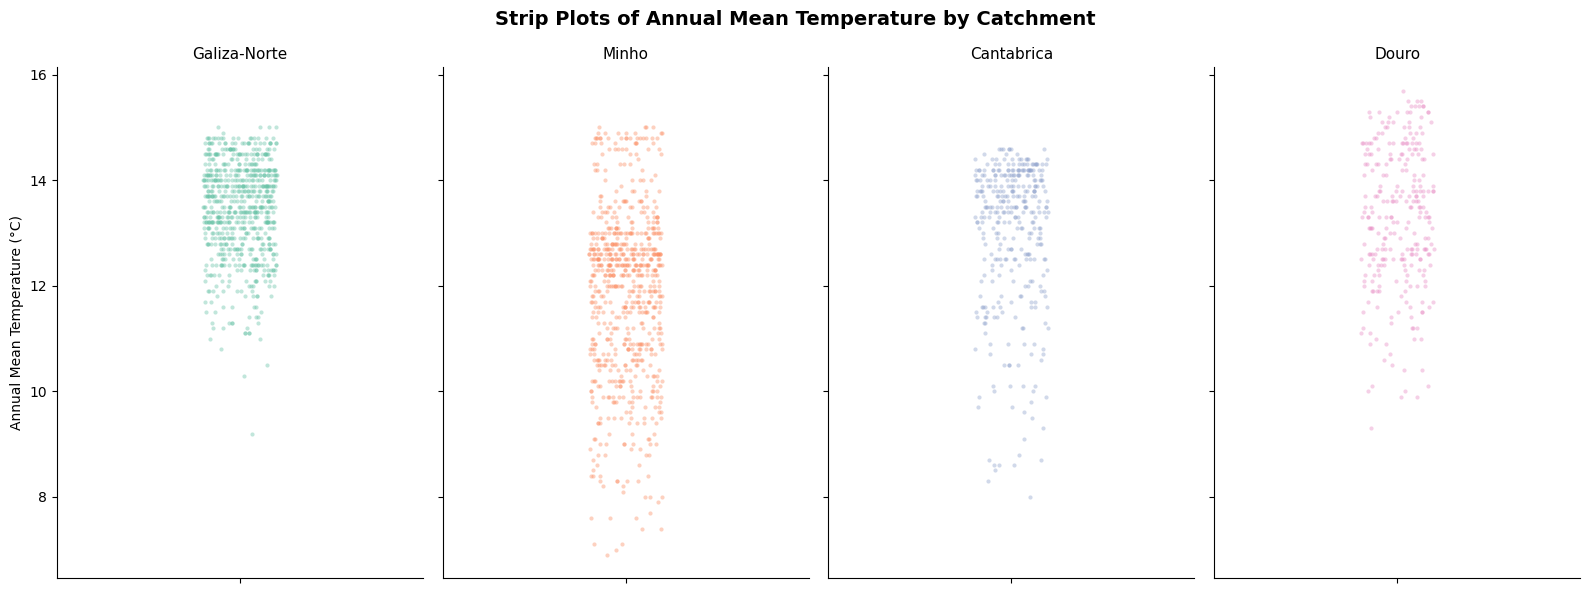

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=True)
fig.suptitle('Strip Plots of Annual Mean Temperature by Catchment', fontsize=14, fontweight='bold')

for ax, catchment in zip(axes, top4):
    data = df_top4[df_top4['Catchment_name'] == catchment]['temp_ann']
    sns.stripplot(
        y=data,
        ax=ax,
        color=palette[catchment],
        alpha=0.4,       # transparency helps reveal overplotting
        size=3,          # smaller dots reduce clutter
        jitter=True      # horizontal jitter separates overlapping points
    )
    ax.set_title(catchment, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Annual Mean Temperature (°C)' if ax == axes[0] else '')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('strip_plots_temp_ann.png', dpi=150, bbox_inches='tight')
plt.show()

Histograms (4 in one window)

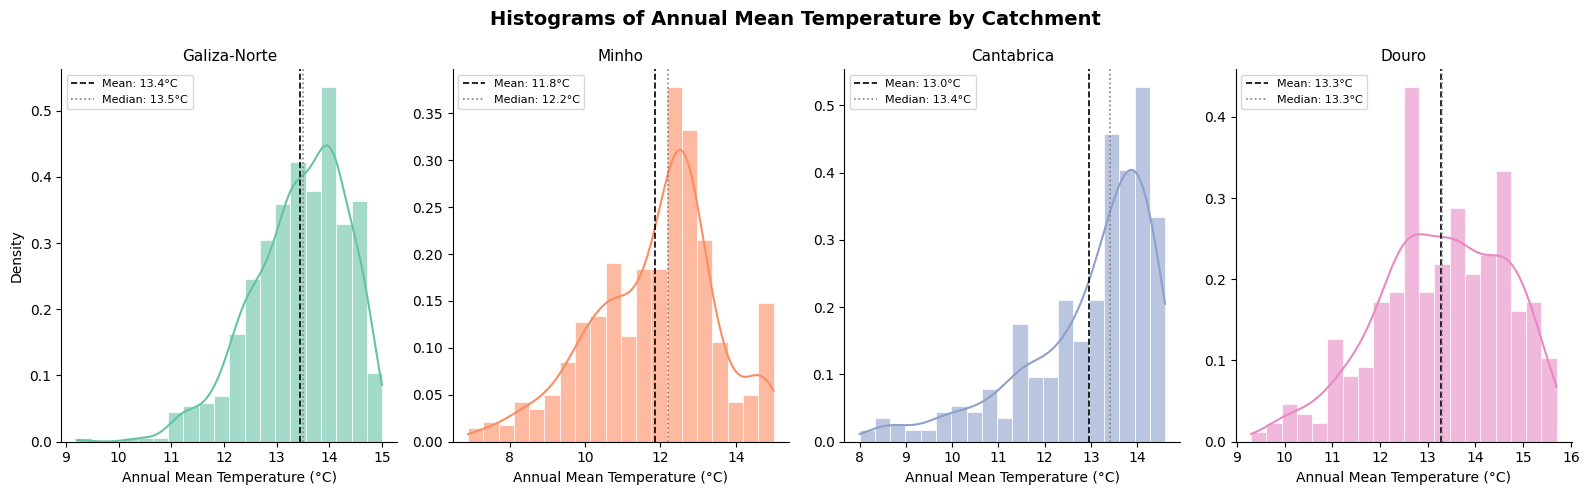

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
fig.suptitle('Histograms of Annual Mean Temperature by Catchment', fontsize=14, fontweight='bold')

for ax, catchment in zip(axes, top4):
    data = df_top4[df_top4['Catchment_name'] == catchment]['temp_ann']
    sns.histplot(
        data,
        ax=ax,
        color=palette[catchment],
        bins=20,
        kde=True,          # overlay KDE curve to show shape
        stat='density',    # density makes KDE and histogram comparable
        alpha=0.6,
        edgecolor='white',
        linewidth=0.5
    )
    # Add vertical lines for mean and median
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.1f}°C')
    ax.axvline(data.median(), color='grey', linestyle=':', linewidth=1.2, label=f'Median: {data.median():.1f}°C')
    ax.set_title(catchment, fontsize=11)
    ax.set_xlabel('Annual Mean Temperature (°C)')
    ax.set_ylabel('Density' if ax == axes[0] else '')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('histograms_temp_ann.png', dpi=150, bbox_inches='tight')
plt.show()

Boxplots (4 in one window)

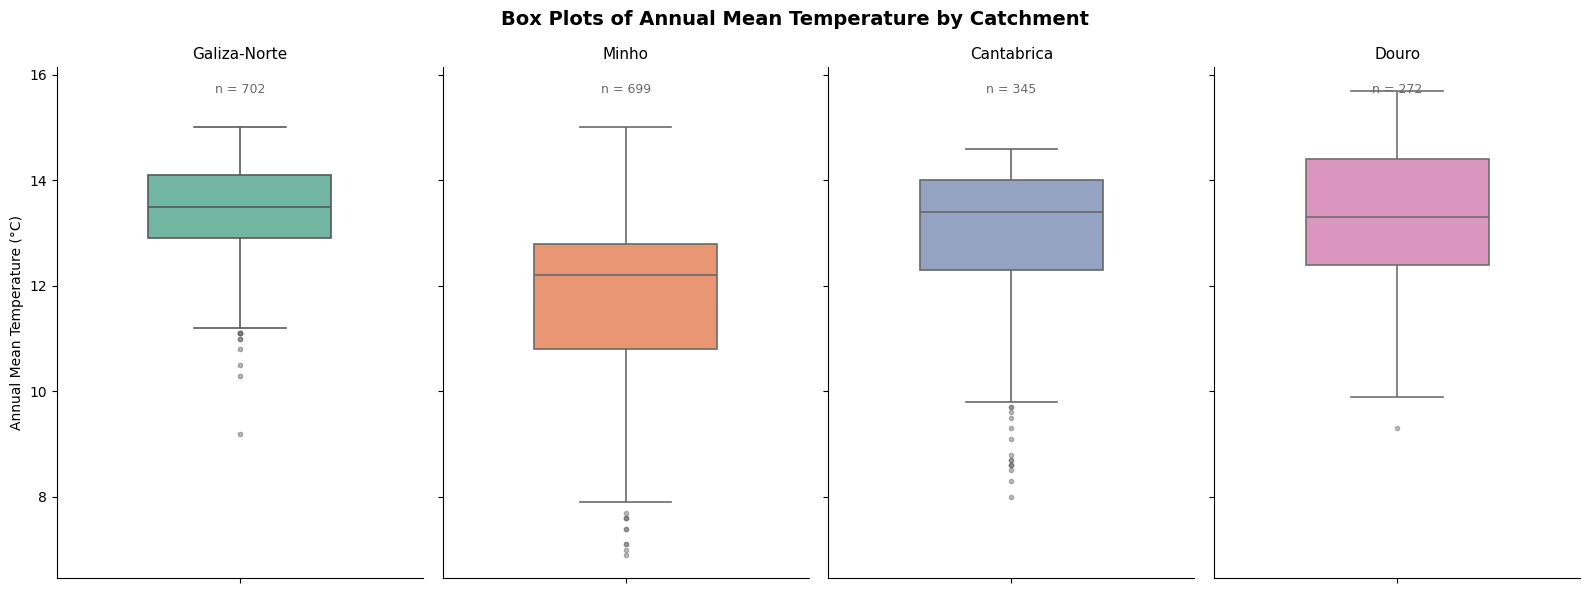

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=True)
fig.suptitle('Box Plots of Annual Mean Temperature by Catchment', fontsize=14, fontweight='bold')

for ax, catchment in zip(axes, top4):
    data = df_top4[df_top4['Catchment_name'] == catchment]['temp_ann']
    sns.boxplot(
        y=data,
        ax=ax,
        color=palette[catchment],
        width=0.5,
        linewidth=1.2,
        flierprops=dict(marker='o', markerfacecolor='grey', markersize=3, alpha=0.5)
    )
    # Annotate with n
    ax.text(0.5, 0.97, f'n = {len(data)}', transform=ax.transAxes,
            ha='center', va='top', fontsize=9, color='dimgray')
    ax.set_title(catchment, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Annual Mean Temperature (°C)' if ax == axes[0] else '')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('boxplots_temp_ann.png', dpi=150, bbox_inches='tight')
plt.show()

Bonus: Violin plots (combines box + distribution, one window)

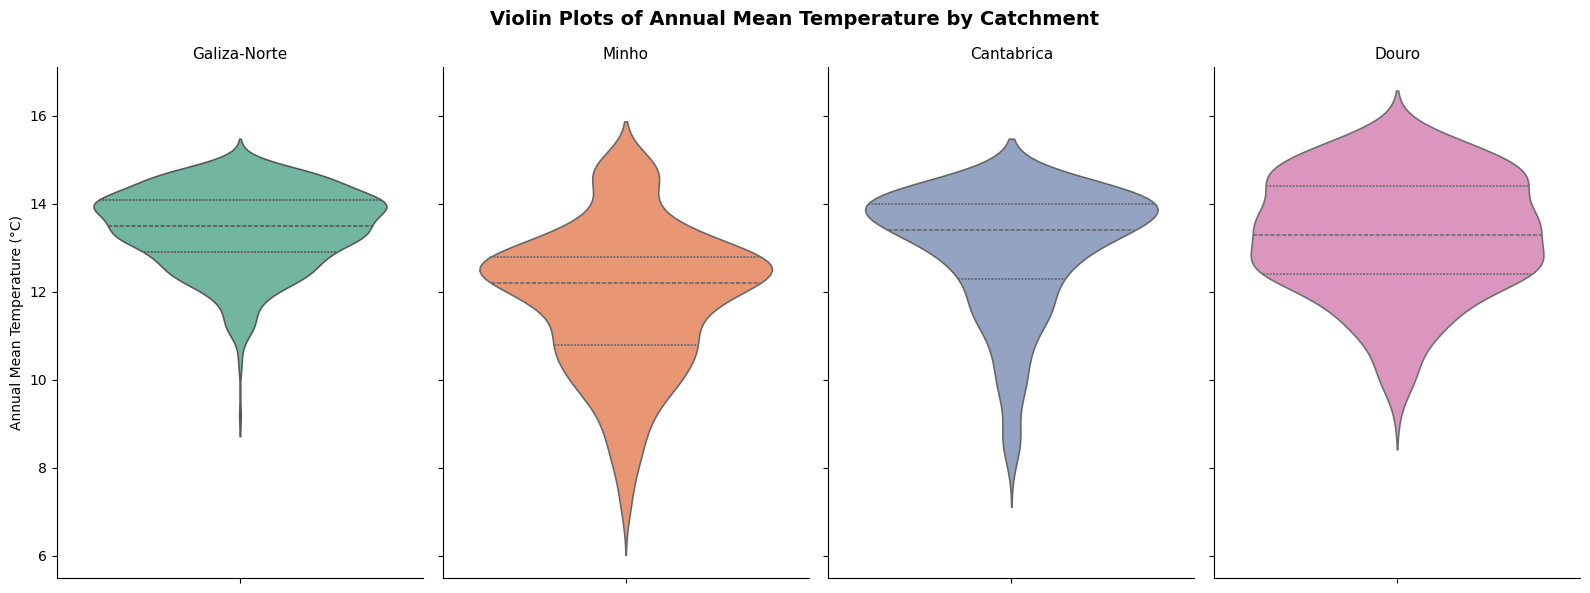

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=True)
fig.suptitle('Violin Plots of Annual Mean Temperature by Catchment', fontsize=14, fontweight='bold')

for ax, catchment in zip(axes, top4):
    data = df_top4[df_top4['Catchment_name'] == catchment]['temp_ann']
    sns.violinplot(
        y=data,
        ax=ax,
        color=palette[catchment],
        inner='quartile',   # show quartile lines inside the violin
        linewidth=1.2
    )
    ax.set_title(catchment, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Annual Mean Temperature (°C)' if ax == axes[0] else '')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('violin_plots_temp_ann.png', dpi=150, bbox_inches='tight')
plt.show()

Challenge: Sampling distribution of the mean
This shows how the sample mean stabilises as sample size grows, using 1000 bootstrap samples at each size.

/tmp/ipykernel_2926/466900695.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


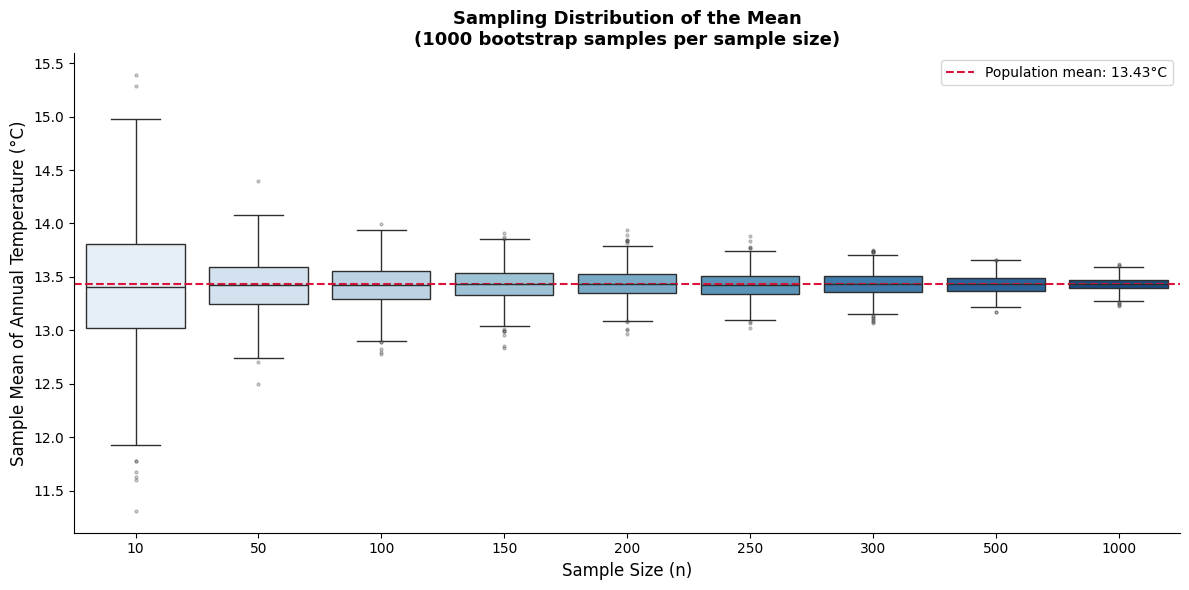

 sample_size  grand_mean      std
          10   13.412460 0.606290
          50   13.421328 0.264001
         100   13.420712 0.195501
         150   13.434836 0.160614
         200   13.439492 0.138422
         250   13.423674 0.121667
         300   13.432976 0.112250
         500   13.428884 0.084658
        1000   13.433328 0.060752


In [7]:
sample_sizes = [10, 50, 100, 150, 200, 250, 300, 500, 1000]
n_samples = 1000
pop = df2['temp_ann'].dropna().values
population_mean = pop.mean()

# Build a dataframe of all sample means
records = []
for n in sample_sizes:
    means = [np.random.choice(pop, size=n, replace=True).mean() for _ in range(n_samples)]
    for m in means:
        records.append({'sample_size': n, 'sample_mean': m})

df_boot = pd.DataFrame(records)

# Summary stats per sample size
summary = df_boot.groupby('sample_size')['sample_mean'].agg(['mean', 'std']).reset_index()
summary.columns = ['sample_size', 'grand_mean', 'std']

# Plot: box plots per sample size + population mean line
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df_boot,
    x='sample_size',
    y='sample_mean',
    ax=ax,
    palette='Blues',
    linewidth=1.0,
    flierprops=dict(marker='o', markersize=2, alpha=0.3, markerfacecolor='grey')
)

# True population mean reference line
ax.axhline(population_mean, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Population mean: {population_mean:.2f}°C')

ax.set_xlabel('Sample Size (n)', fontsize=12)
ax.set_ylabel('Sample Mean of Annual Temperature (°C)', fontsize=12)
ax.set_title('Sampling Distribution of the Mean\n(1000 bootstrap samples per sample size)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('sampling_distribution_mean.png', dpi=150, bbox_inches='tight')
plt.show()

# Optional: print the spread at each sample size
print(summary.to_string(index=False))

**What each plot tells you — pros and cons**

Strip plot

✅ Shows every individual data point — no information is hidden
✅ Excellent for small to medium samples; you can literally see clusters, gaps, and outliers
❌ At large n (e.g. Galiza-Norte, n=702) heavy overplotting makes it hard to judge density even with jitter and transparency

Histogram

✅ Clearly communicates the shape of the distribution (symmetry, skewness, modality)
✅ The KDE overlay makes smooth shape comparison easier
❌ Sensitive to bin width — different choices can suggest different stories
❌ Hides the total n and can obscure outliers

Boxplot

✅ Compact and very efficient for comparing median, IQR, and outliers across groups
✅ Robust to large n — works equally well whether n=10 or n=10000
❌ Can completely mask bimodality or skewed tails that would be obvious in a histogram
❌ Two very different distributions can produce almost identical boxplots

Violin plot (bonus)

✅ Combines the distributional detail of a histogram with the summary of a boxplot
❌ Can be misleading with small samples because the KDE is smoothed beyond what the data justify

**Sampling distribution challenge**

The boxplots visibly tighten as n increases. By n ≈ 100–150 the spread is already quite small; by n = 300 the sample mean is consistently within ~0.1–0.2°C of the true population mean. This is the Central Limit Theorem at work — the standard error of the mean shrinks as 1/√n.